<a href="https://colab.research.google.com/github/SivaSwetha-baba/my_first_repo/blob/main/modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
survived
0    549
1    342
Name: count, dtype: int64

Class percentages:
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64
Training shape: (712, 14)
Testing shape: (179, 14)
Logistic Regr

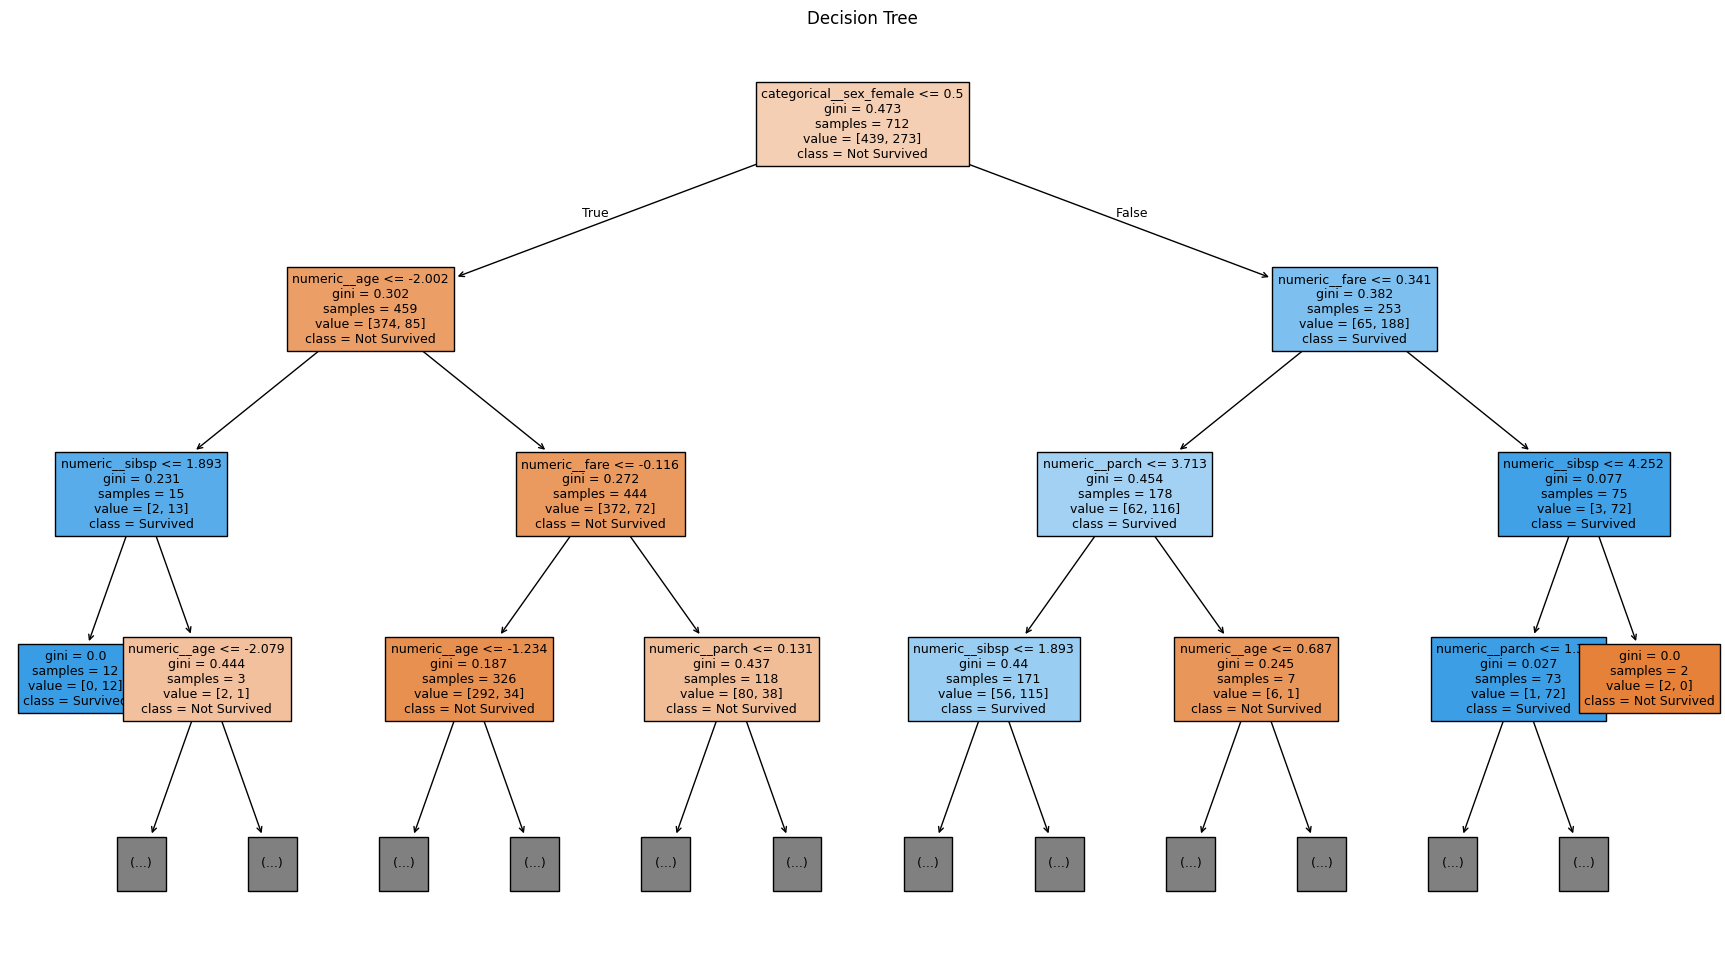

                     Accuracy  Precision  Recall      F1     AUC
Logistic Regression    0.7989     0.7797  0.6667  0.7188  0.8194
Decision Tree          0.7709     0.7059  0.6957  0.7007  0.7514
Random Forest          0.7765     0.7377  0.6522  0.6923  0.8240


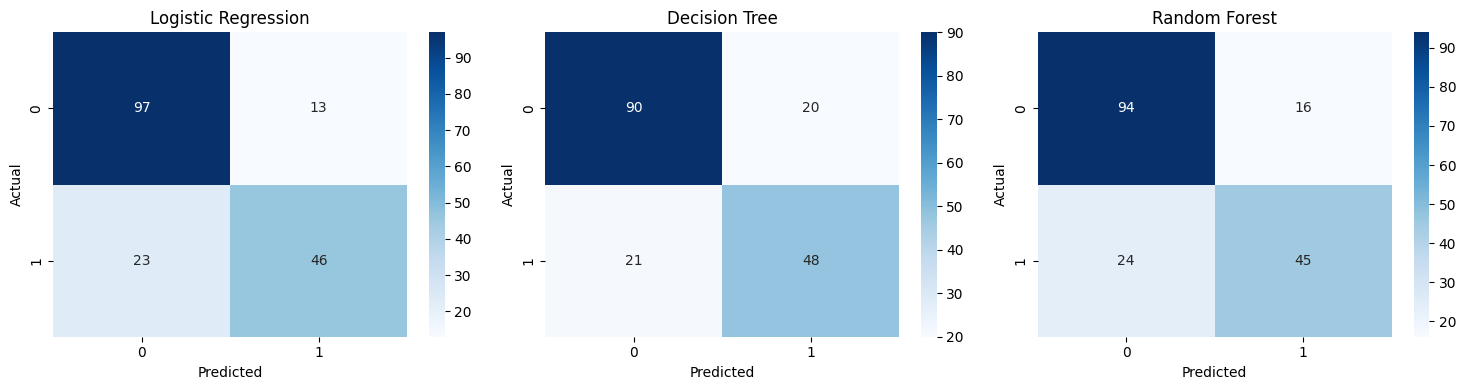

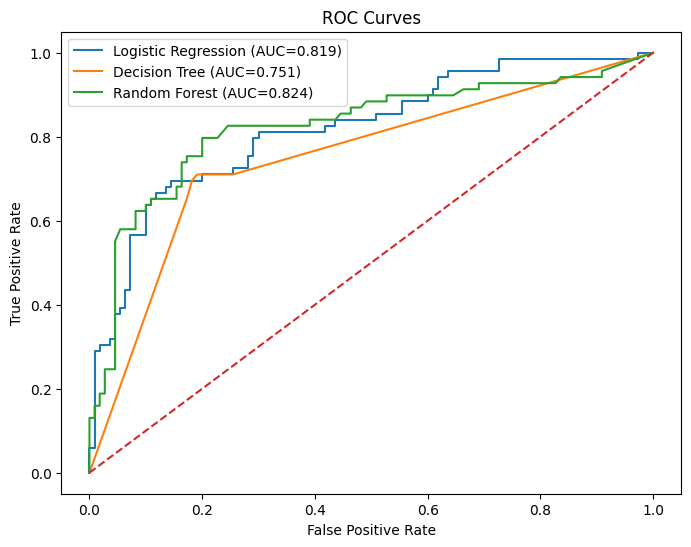

                       Precision  Recall      F1
Baseline                  0.7797  0.6667  0.7188
Class Weight Balanced     0.7385  0.6957  0.7164
SMOTE                     0.7385  0.6957  0.7164
Best parameters:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__n_estimators': 300}
Best CV F1:
0.7503737799064902
OOB score:
0.8117977528089888
MAE: 20.897717925140885
RMSE: 30.53280256139836
R²: 0.3975480238022152
Adjusted R²: 0.3616877871237756


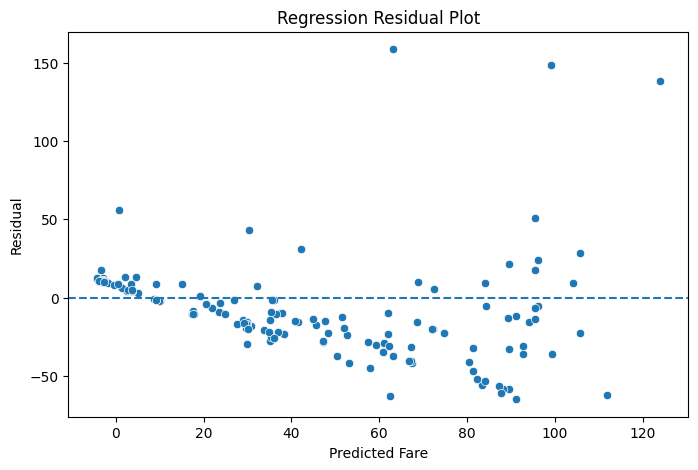

CLASSIFICATION METRICS
                     Accuracy  Precision  Recall      F1     AUC
Logistic Regression    0.7989     0.7797  0.6667  0.7188  0.8194
Decision Tree          0.7709     0.7059  0.6957  0.7007  0.7514
Random Forest          0.7765     0.7377  0.6522  0.6923  0.8240

REGRESSION METRICS
                       MAE     RMSE      R²  Adjusted R²
Linear Regression  20.8977  30.5328  0.3975       0.3617


NameError: name 'joblib' is not defined

In [ ]:
import seaborn as sns
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from matplotlib import pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import numpy as np


df = sns.load_dataset("titanic")

print(df.shape)
print(df.head())


#Checking clas balance

print(df["survived"].value_counts())

print("\nClass percentages:")
print(
    df["survived"]
    .value_counts(normalize=True)
    .mul(100)
)


X = df.drop(columns=["survived"])
y = df["survived"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

'''Interpretation for stratify

The Titanic target is not perfectly balanced because the number of passengers who survived differs from the number who did not survive. Stratification preserves approximately the same survived/not-survived proportion in both training and testing sets. This makes the evaluation more representative and reduces the possibility that one split receives an unusual class distribution.'''


numeric_features = [
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

#adding pclass now in numerical_features after the scaling

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]


logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(max_iter=1000)
        )
    ]
)


tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

from sklearn.ensemble import RandomForestClassifier

forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": forest_pipeline
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully.")


tree_preprocessor = tree_pipeline.named_steps["preprocessor"]

feature_names = tree_preprocessor.get_feature_names_out()

tree_model = tree_pipeline.named_steps["model"]



plt.figure(figsize=(22, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree")
plt.show()

#Evaluation function

def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, predictions)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    auc = roc_auc_score(y_test, probabilities)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm,
        "probabilities": probabilities
    }


results = {}

for name, model in models.items():

    results[name] = evaluate_model(
        model,
        X_test,
        y_test
    )

comparison = pd.DataFrame({
    name: {
        "Accuracy": result["accuracy"],
        "Precision": result["precision"],
        "Recall": result["recall"],
        "F1": result["f1"],
        "AUC": result["auc"]
    }
    for name, result in results.items()
}).T

print(comparison.round(4))

#confusion matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, result) in zip(
    axes,
    results.items()
):

    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

#ROC curve

plt.figure(figsize=(8, 6))

for name, result in results.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        result["probabilities"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={result['auc']:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")

plt.legend()
plt.show()


baseline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(max_iter=1000)
        )
    ]
)

baseline.fit(X_train, y_train)

#class weighing

balanced = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

balanced.fit(X_train, y_train)

#SMOTE

smote_model = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        (
            "model",
            LogisticRegression(max_iter=1000)
        )
    ]
)

smote_model.fit(X_train, y_train)

#comparing them


imbalance_models = {
    "Baseline": baseline,
    "Class Weight Balanced": balanced,
    "SMOTE": smote_model
}

imbalance_results = {}

for name, model in imbalance_models.items():

    prediction = model.predict(X_test)

    imbalance_results[name] = {
        "Precision": precision_score(
            y_test,
            prediction
        ),
        "Recall": recall_score(
            y_test,
            prediction
        ),
        "F1": f1_score(
            y_test,
            prediction
        )
    }

imbalance_table = pd.DataFrame(
    imbalance_results
).T

print(imbalance_table.round(4))

oob_score=True
rf_for_grid = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                oob_score=True
            )
        )
    ]
)

#Grid

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__max_features": ["sqrt", "log2"]
}

#GridSearch

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=rf_for_grid,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print("Best CV F1:")
print(grid_search.best_score_)
best_rf_pipeline = grid_search.best_estimator_

best_rf_model = best_rf_pipeline.named_steps["model"]

print("OOB score:")
print(best_rf_model.oob_score_)

regression_features = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "sex",
    "embarked"
]

X_reg = df[regression_features]
y_reg = df["fare"]


X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

reg_numeric = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical = [
    "sex",
    "embarked"
]

reg_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

reg_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            reg_numeric_pipeline,
            reg_numeric
        ),
        (
            "categorical",
            reg_categorical_pipeline,
            reg_categorical
        )
    ]
)

from sklearn.linear_model import LinearRegression

regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("model", LinearRegression())
    ]
)

regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

y_reg_pred = regression_pipeline.predict(
    X_reg_test
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred
    )
)

r2 = r2_score(
    y_reg_test,
    y_reg_pred
)

n = len(y_reg_test)

# Number of predictors after one-hot encoding
X_reg_test_transformed = (
    regression_pipeline
    .named_steps["preprocessor"]
    .transform(X_reg_test)
)

p = X_reg_test_transformed.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1)
    / (n - p - 1)
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)

residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_reg_pred,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Regression Residual Plot")

plt.show()

classification_table = comparison.copy()

#classification_table

regression_table = pd.DataFrame({
    "MAE": [mae],
    "RMSE": [rmse],
    "R²": [r2],
    "Adjusted R²": [adjusted_r2]
}, index=["Linear Regression"])

print("CLASSIFICATION METRICS")
print(classification_table.round(4))

print("\nREGRESSION METRICS")
print(regression_table.round(4))

joblib.dump(
    best_rf_pipeline,
    "best_titanic_pipeline.joblib"
)

print("Complete pipeline saved.")

loaded_pipeline = joblib.load(
    "best_titanic_pipeline.joblib"
)

print("Pipeline successfully reloaded.")

raw_sample = X_test.iloc[[0]]

print("Raw input:")
print(raw_sample)
prediction = loaded_pipeline.predict(raw_sample)

print("Prediction:", prediction)

probability = loaded_pipeline.predict_proba(
    raw_sample
)

print("Prediction probabilities:")
print(probability)